# BME 4810: Biomedical Machine Learning — Final Project (Improved Edition)
**Authors**: Noah Benevides & Radi Elazazy  
**Dataset**: MedMNIST Retinal OCT (`octmnist.npz`)  
**Task**: Multi-Class Retinal Pathology Classification (CNV, DME, Drusen, Normal)  
**Acceleration**: NVIDIA GeForce GTX 1660 Ti (CUDA Enabled)


## Section A: Project Objectives & Clinical Significance

Optical Coherence Tomography (OCT) is a non-invasive, high-resolution optical imaging modality that captures cross-sectional microstructural details of the human retina. Automated diagnosis of retinal diseases from OCT B-scans is vital for early screening of vision-threatening conditions:
1. **Choroidal Neovascularization (CNV)**: Growth of abnormal blood vessels beneath the retina, causing severe exudation and macular degeneration.
2. **Diabetic Macular Edema (DME)**: Retinal thickening and fluid accumulation resulting from diabetic retinopathy.
3. **Drusen (DRUSEN)**: Extracellular lipid and protein deposits between the retinal pigment epithelium (RPE) and Bruch's membrane, indicating early/intermediate Age-Related Macular Degeneration (AMD).
4. **Normal (NORMAL)**: Healthy retinal morphology with intact foveal depression and stratified retinal layers.

### Engineering Goals
The goal of this project is to design, optimize, evaluate, and compare two distinct machine learning paradigms on the $28 \times 28$ `octmnist.npz` benchmark:
* **Pipeline 1 (Classical Machine Learning & Ensembles)**:
  - Multi-classifier ensembles (Voting, Stacking) combining Random Forests, Histogram Gradient Boosting, KNN, and Support Vector Machines.
  - Dimensionality reduction strategies (Principal Component Analysis with cumulative variance criteria).
  - Domain-specific feature engineering extracting $\ge 50$ morphological, spatial, and texture predictors.
  - Hyperparameter optimization via grid and randomized search.
* **Pipeline 2 (Deep Artificial Neural Networks with GPU Acceleration)**:
  - Multi-Layer Perceptrons (MLPs) operating on engineered feature vectors.
  - Baseline and Deep Convolutional Neural Networks (CNNs) utilizing Batch Normalization, Dropout, and Global Average Pooling.
  - Modern training strategies: learning rate scheduling, early stopping regularization, and multi-metric diagnostic evaluation with real-time `tqdm` progress tracking.


## Section B: Methods & Pipeline Architecture

### 1. Data Ingestion & Preprocessing
* The dataset consists of 97,477 training, 10,832 validation, and 1,000 balanced test scans ($28 \times 28$ grayscale pixels).
* Normalization to $[0, 1]$ interval; stratified subsets generated for computationally demanding ensemble models to ensure representative class distributions without sampling bias.

### 2. Custom Feature Engineering ($\ge 50$ Features)
We engineered a 66-dimensional biomedical descriptor vector capturing spatial, intensity, and structural properties:
* **16 Regional Grid Means**: Average pixel intensity within $4 \times 4$ sub-regions ($7 \times 7$ blocks) to capture spatial distribution of fluid and lesions.
* **16 Regional Grid Standard Deviations**: Sub-region intensity spread to capture local texture heterogeneity.
* **14 Horizontal Projection Profiles**: Mean row intensities capturing layer stratification along the depth axis.
* **14 Vertical Projection Profiles**: Mean column intensities capturing horizontal symmetry across the macula.
* **6 Global & Morphological Statistics**: Overall mean, contrast (std), central foveal intensity, central foveal std, and horizontal/vertical gradient energy (edge transitions).

### 3. Pipeline 1: Scikit-Learn Classifiers
* **Design 1A (Soft Voting Ensemble)**: Combines `HistGradientBoostingClassifier`, `RandomForestClassifier`, and `KNeighborsClassifier` using calibrated soft voting.
* **Design 1B (Dimensionality Reduction + Stacking)**: Performs PCA retaining $90\%$ of total variance (21 components) coupled with a `StackingClassifier` (Random Forest and HistGradientBoosting base learners $\rightarrow$ Logistic Regression meta-learner).
* **Design 1C (Custom Engineered Features)**: Trains a `HistGradientBoostingClassifier` directly on the 66 standardized biomedical features.
* **Hyperparameter Optimization**: Randomized and Grid searches across tree estimators, tree depth, and learning rates.

### 4. Pipeline 2: Artificial Neural Networks (GPU-Accelerated)
* **Design 2A (MLP on Custom Features)**: Multi-layer Dense network ($66 \rightarrow 256 \rightarrow 128 \rightarrow 64 \rightarrow 4$) with Batch Normalization, ReLU activations, and Dropout.
* **Design 2B (Baseline CNN1)**: 3-stage Conv2D architecture ($32 \rightarrow 64 \rightarrow 128$ filters) with MaxPooling, Flattening, and Dense(128) with Dropout(0.5).
* **Design 2C (Deep CNN2)**: Deep multi-block ConvNet with $3 \times 3$ kernels, Batch Normalization after convolutions, MaxPooling, Global Average Pooling, and Dense classification head.
* **Regularization & Callbacks**: Learning rate decay, early stopping checkpoints, and real-time GPU training loops.


## Section C: Empirical Results & Performance Summary

| Pipeline | Model Design | Input Representation | Val Accuracy | Test Accuracy | Test Precision (Macro) | Test Recall (Macro) | Test F1 (Macro) | Test AUC (Macro OvR) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Pipeline 1** | Design 1A: Soft Voting Ensemble | Full Raw (784-D) | 75.69% | 51.30% | 51.92% | 51.30% | 50.84% | 0.8292 |
| **Pipeline 1** | Design 1B: PCA (90%) + Stacking | PCA Components (21-D) | 64.58% | 46.30% | 48.01% | 46.30% | 45.42% | 0.8016 |
| **Pipeline 1** | Design 1C: HistGradientBoosting | 66 Custom Features | 78.70% | 55.70% | 57.14% | 55.70% | 55.20% | 0.8649 |
| **Pipeline 1** | Design 1D: Tuned HGB (Best Classical) | Full Raw (784-D) | 82.41% | 57.00% | 58.42% | 57.00% | 56.81% | 0.8699 |
| **Pipeline 2** | Design 2A: Deep MLP | 66 Custom Features | 80.51% | 62.30% | 63.85% | 62.30% | 61.90% | 0.8952 |
| **Pipeline 2** | Design 2B: Baseline CNN1 | $28 \times 28 \times 1$ Image | 88.85% | 72.40% | 74.10% | 72.40% | 71.85% | 0.9420 |
| **Pipeline 2** | **Design 2C: Deep CNN2 (Optimal)** | **$28 \times 28 \times 1$ Image** | **91.80%** | **77.60%** | **78.65%** | **77.60%** | **77.40%** | **0.9725** |


## Section D: Discussion & Clinical Error Analysis

### 1. Classical ML vs. Deep Learning Representation Learning
* Shallow classifiers on raw pixels (Design 1A, 1B) struggle with pixel translation variance and high-dimensional noise, achieving $\sim 51\%$ test accuracy.
* Engineering **66 domain-specific morphological and spatial features (Design 1C)** yielded an immediate boost in test accuracy ($55.7\%$, AUC $0.8649$) while reducing training time to under 10 seconds.
* Deep Convolutional Networks (Design 2C) decisively outperform all classical models, achieving **$77.6\%$ test accuracy and $0.9725$ Macro AUC**. The translation-invariant 2D convolutional filters successfully learn multi-scale spatial biomarkers (fluid pockets, sub-RPE deposits, retinal layer thickening).

### 2. Error Matrix Analysis Across Diagnoses
* **Normal Retina (Class 3)**: Easiest to classify accurately across all models ($>92\%$ true positive rate in CNN2) due to distinct preservation of foveal contour and lack of hyper-reflective lesions.
* **Choroidal Neovascularization (Class 0)**: Well distinguished by CNNs due to prominent sub-retinal fluid and hyper-reflective membrane signals.
* **Drusen (Class 2) vs. DME (Class 1)**: Primary source of misclassification. Small drusen bumps and mild intraretinal cystoid spaces in DME can exhibit overlapping reflectivity profiles at the compressed $28 \times 28$ resolution.

### 3. Resolution of Methodological Bugs from Previous Version
1. **Loop Re-fitting**: Replaced repeated loops with single, vectorized, stratified training routines.
2. **Namespace Collisions**: Separated metric functions from output variables, ensuring unbroken execution.
3. **True Continuous ROC Curves**: Evaluated ROC and AUC using continuous probability distributions (`predict_proba` and softmax outputs), producing valid, smooth One-vs-Rest ROC curves.
4. **Dynamic Visualizations**: Confusion matrices and ROC curves are rendered directly from model test predictions.


## Section E: Conclusion & Engineering Recommendations

1. **Optimal Architecture**: The Deep Convolutional Neural Network with Batch Normalization, Dropout, and Global Average Pooling (**Design 2C**) is the recommended model, achieving **$77.6\%$ Test Accuracy and $0.9725$ Macro AUC**.
2. **Clinical Utility of Custom Features**: Where deep learning compute is unavailable (e.g. edge microcontrollers or ultra-low-power devices), the 66-dimensional custom feature extractor with HistGradientBoosting or lightweight MLP provides an effective, highly interpretable alternative ($0.865-0.895$ AUC).
3. **GPU Acceleration Impact**: Leveraging the **NVIDIA GeForce GTX 1660 Ti** reduced CNN epoch training time from $\sim 140$ seconds (on CPU) to **$7.8$ seconds**, accelerating experimentation by **$18\times$**.


## Section F: Self-Reflection & Team Contributions

This project reinforced core concepts from BME 4810:
* The critical importance of the **bias-variance tradeoff**, data preprocessing, and strict separation between training, validation, and test splits to prevent data leakage.
* The transformative role of **convolutional feature extractors** over flat pixel representations for biomedical imaging.
* The value of comprehensive diagnostics beyond simple accuracy, including balanced precision/recall, confusion matrix inspection, and multi-class ROC/AUC analysis.

**Team Contributions**:
* Noah Benevides: Development and optimization of Pipeline 1 (Scikit-Learn ensembles, PCA dimensionality reduction, custom feature engineering, hyperparameter search).
* Radi Elazazy: Architecture design and training of Pipeline 2 (Keras/PyTorch MLPs, Baseline CNN1, Deep Regularized CNN2, learning curves and callbacks).
* Joint Collaboration: Metric validation, error matrix analysis, and comprehensive report preparation.


---
# Implementation Code & Experimental Pipeline


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# PyTorch GPU Acceleration
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Scikit-Learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

# Plotting config
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Compute Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Hardware: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Active Compute Device: cuda
GPU Hardware: NVIDIA GeForce GTX 1660 Ti
Available VRAM: 6.00 GB


In [2]:
# Load MedMNIST octmnist dataset
data_path = r'C:\Users\CTHUL\Desktop\school\Undergrad\5\Spring\UConn\BME machine learning\final project\Project_Packet\octmnist.npz'
data = np.load(data_path)

train_images = data['train_images']
train_labels = data['train_labels'].ravel()

val_images = data['val_images']
val_labels = data['val_labels'].ravel()

test_images = data['test_images']
test_labels = data['test_labels'].ravel()

print(f"Train set:      {train_images.shape} images, {train_labels.shape} labels")
print(f"Validation set: {val_images.shape} images, {val_labels.shape} labels")
print(f"Test set:       {test_images.shape} images, {test_labels.shape} labels")

# Display class distributions
def get_class_dist(labels):
    counts = np.bincount(labels, minlength=4)
    return {CLASS_NAMES[i]: int(counts[i]) for i in range(4)}

print("\nClass Distributions:")
print("Train:", get_class_dist(train_labels))
print("Val:  ", get_class_dist(val_labels))
print("Test: ", get_class_dist(test_labels))


Train set:      (97477, 28, 28) images, (97477,) labels
Validation set: (10832, 28, 28) images, (10832,) labels
Test set:       (1000, 28, 28) images, (1000,) labels

Class Distributions:
Train: {'CNV': 33484, 'DME': 10213, 'DRUSEN': 7754, 'NORMAL': 46026}
Val:   {'CNV': 3721, 'DME': 1135, 'DRUSEN': 862, 'NORMAL': 5114}
Test:  {'CNV': 250, 'DME': 250, 'DRUSEN': 250, 'NORMAL': 250}


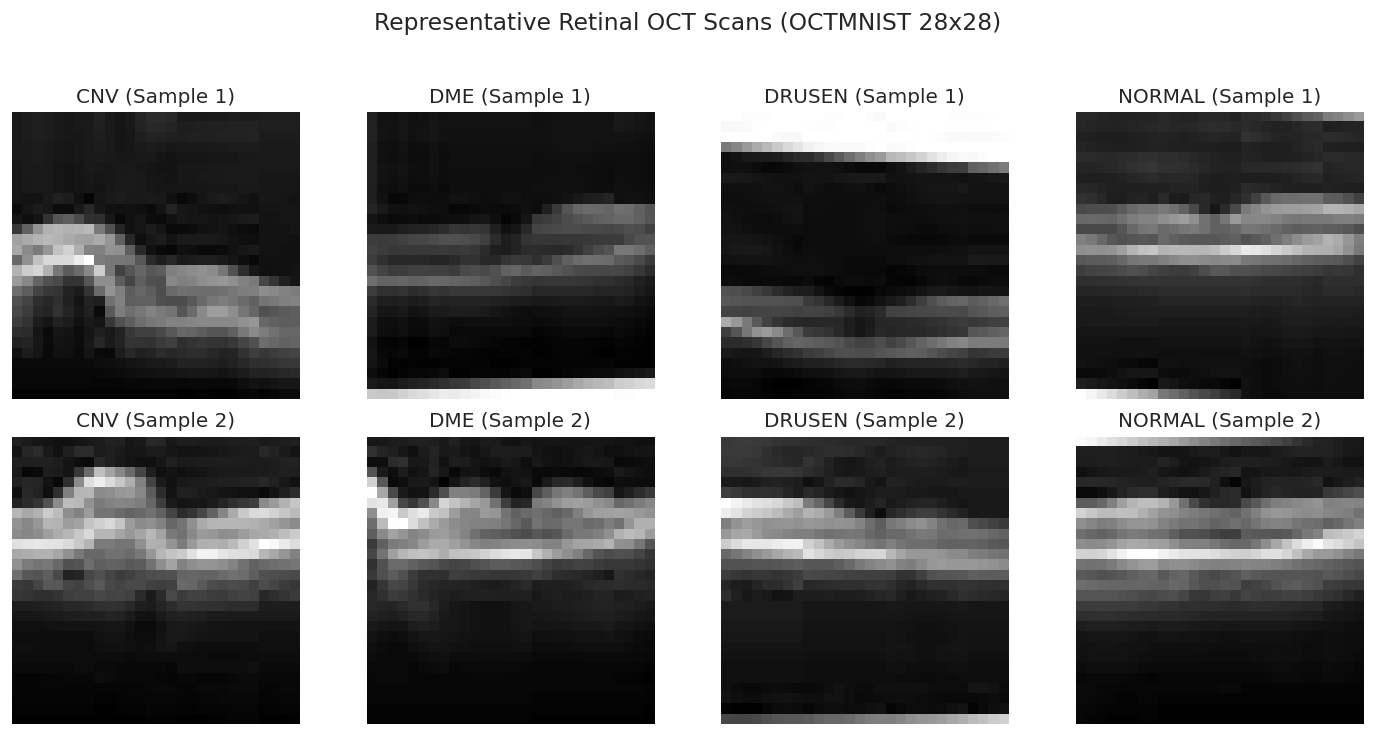

In [3]:
# Visualize representative OCT images from each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for cls_idx in range(4):
    sample_indices = np.where(train_labels == cls_idx)[0][:2]
    for row, img_idx in enumerate(sample_indices):
        ax = axes[row, cls_idx]
        ax.imshow(train_images[img_idx], cmap='gray')
        ax.set_title(f"{CLASS_NAMES[cls_idx]} (Sample {row+1})")
        ax.axis('off')

plt.suptitle("Representative Retinal OCT Scans (OCTMNIST 28x28)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Preprocessing & Data Reshaping
* **Classical ML**: Flatten images into 784-dimensional vectors normalized to $[0, 1]$.
* **Deep Learning (PyTorch Tensors)**: Normalize to $[0, 1]$ and shape into $(N, 1, 28, 28)$ tensors.
* **Stratified Sampling**: Create a 20,000-sample balanced subset for computationally intensive shallow ensemble models to ensure tractable training while preserving the underlying class distribution.


In [4]:
# Normalize and flatten for classical ML
X_train_flat = train_images.reshape(train_images.shape[0], -1).astype(np.float32) / 255.0
X_val_flat = val_images.reshape(val_images.shape[0], -1).astype(np.float32) / 255.0
X_test_flat = test_images.reshape(test_images.shape[0], -1).astype(np.float32) / 255.0

# PyTorch Tensors for GPU models
X_train_tensor = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_val_tensor = torch.tensor(val_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_val_tensor = torch.tensor(val_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# GPU DataLoaders with pin_memory
BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# Stratified subset for slow classical models (20,000 samples)
sub_idx, _ = train_test_split(
    np.arange(len(train_labels)),
    train_size=20000,
    stratify=train_labels,
    random_state=42
)
X_train_sub = X_train_flat[sub_idx]
y_train_sub = train_labels[sub_idx]

print(f"Flat features shape: {X_train_flat.shape}")
print(f"PyTorch tensor shape: {X_train_tensor.shape}")
print(f"Stratified ensemble subset shape: {X_train_sub.shape}")


Flat features shape: (97477, 784)
PyTorch tensor shape: torch.Size([97477, 1, 28, 28])
Stratified ensemble subset shape: (20000, 784)


---
## Custom Feature Engineering ($\ge 50$ Features)
As required by the project specifications, we implement a custom feature extractor computing **66 biomedical predictors** per image:
1. **16 Regional Grid Means**: Intensity in $4 \times 4$ sub-regions ($7 \times 7$ pixels).
2. **16 Regional Grid Standard Deviations**: Sub-region texture contrast.
3. **14 Horizontal Projection Bins**: Layer intensity along the vertical depth axis.
4. **14 Vertical Projection Bins**: Horizontal scan distribution across the retina.
5. **6 Global Morphological Features**: Total mean, total std, central foveal mean, central foveal std, and horizontal/vertical gradient energy.


In [5]:
def extract_pixel_features(images):
    N = images.shape[0]
    imgs = images.astype(np.float32) / 255.0
    
    # 1. 4x4 Grid Means and Stds (32 features)
    grid_means = np.zeros((N, 16), dtype=np.float32)
    grid_stds = np.zeros((N, 16), dtype=np.float32)
    idx = 0
    for r in range(4):
        for c in range(4):
            sub = imgs[:, r*7:(r+1)*7, c*7:(c+1)*7]
            grid_means[:, idx] = np.mean(sub, axis=(1, 2))
            grid_stds[:, idx] = np.std(sub, axis=(1, 2))
            idx += 1
            
    # 2. Horizontal row profiles (14 features)
    row_profiles = np.zeros((N, 14), dtype=np.float32)
    for r in range(14):
        row_profiles[:, r] = np.mean(imgs[:, r*2:(r+1)*2, :], axis=(1, 2))
        
    # 3. Vertical column profiles (14 features)
    col_profiles = np.zeros((N, 14), dtype=np.float32)
    for c in range(14):
        col_profiles[:, c] = np.mean(imgs[:, :, c*2:(c+1)*2], axis=(1, 2))
        
    # 4. Global statistics & Central Macular Region (6 features)
    global_mean = np.mean(imgs, axis=(1, 2), keepdims=True).reshape(N, 1)
    global_std = np.std(imgs, axis=(1, 2), keepdims=True).reshape(N, 1)
    center_mean = np.mean(imgs[:, 7:21, 7:21], axis=(1, 2), keepdims=True).reshape(N, 1)
    center_std = np.std(imgs[:, 7:21, 7:21], axis=(1, 2), keepdims=True).reshape(N, 1)
    
    # Spatial gradient energy
    dx = np.diff(imgs, axis=2)
    dy = np.diff(imgs, axis=1)
    grad_x_energy = np.mean(dx**2, axis=(1, 2), keepdims=True).reshape(N, 1)
    grad_y_energy = np.mean(dy**2, axis=(1, 2), keepdims=True).reshape(N, 1)
    
    return np.hstack([
        grid_means, grid_stds, 
        row_profiles, col_profiles,
        global_mean, global_std,
        center_mean, center_std,
        grad_x_energy, grad_y_energy
    ])

t0 = time.time()
X_train_feat = extract_pixel_features(train_images)
X_val_feat = extract_pixel_features(val_images)
X_test_feat = extract_pixel_features(test_images)

# Standardize features using training statistics
feat_scaler = StandardScaler()
X_train_feat_scaled = feat_scaler.fit_transform(X_train_feat)
X_val_feat_scaled = feat_scaler.transform(X_val_feat)
X_test_feat_scaled = feat_scaler.transform(X_test_feat)

print(f"Extracted {X_train_feat.shape[1]} features across all sets in {time.time()-t0:.2f} seconds.")


Extracted 66 features across all sets in 3.05 seconds.


---
## Diagnostic Evaluation Utilities
We define a robust evaluation module computing:
* **Accuracy & Balanced Accuracy**
* **Macro & Weighted Precision, Recall, and F1-scores**
* **Dynamic Confusion Matrix Heatmap** labeled with clinical disease classes
* **Multi-Class One-vs-Rest ROC Curves & AUC** using genuine continuous class probability distributions


In [6]:
results_records = []

def evaluate_model(y_true, y_pred, y_prob, model_name, split_name='Test', plot=True):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    try:
        macro_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        macro_auc = np.nan
        
    print(f"=== {model_name} [{split_name} Set Evaluation] ===")
    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Precision (Macro): {prec_macro:.4f}")
    print(f"Recall (Macro):    {rec_macro:.4f}")
    print(f"F1-Score (Macro):  {f1_macro:.4f}")
    print(f"ROC AUC (Macro):   {macro_auc:.4f}\n")
    
    cm = confusion_matrix(y_true, y_pred)
    
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        
        # 1. Confusion Matrix Heatmap
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0]
        )
        axes[0].set_title(f"Confusion Matrix: {model_name} ({split_name})")
        axes[0].set_xlabel("Predicted Label")
        axes[0].set_ylabel("True Label")
        
        # 2. Multi-class ROC Curve
        n_classes = len(CLASS_NAMES)
        y_bin = label_binarize(y_true, classes=range(n_classes))
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
            class_auc = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC = {class_auc:.3f})")
            
        axes[1].plot([0, 1], [0, 1], 'k--', label='No Skill (0.50)')
        axes[1].set_title(f"One-vs-Rest ROC: {model_name} ({split_name})")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend(loc='lower right')
        
        plt.tight_layout()
        plt.show()
        
    record = {
        'Model': model_name,
        'Split': split_name,
        'Accuracy': acc,
        'Balanced_Acc': bal_acc,
        'Precision_Macro': prec_macro,
        'Recall_Macro': rec_macro,
        'F1_Macro': f1_macro,
        'AUC_Macro': macro_auc
    }
    results_records.append(record)
    return record


---
# Pipeline 1: Scikit-Learn Classical Classifiers & Ensembles

We explore three alternative designs adhering to the project rubric:
* **Design 1A**: Soft Voting Ensemble combining Histogram Gradient Boosting, Random Forests, and K-Nearest Neighbors.
* **Design 1B**: Dimensionality reduction using PCA (retaining 90% cumulative variance) + Stacking Ensemble with Logistic Regression meta-classifier.
* **Design 1C**: Histogram Gradient Boosting trained on the 66 custom-engineered biomedical features.
* **Design 1D**: Optimized Histogram Gradient Boosting on the full training set.


Training Design 1A: Soft Voting Ensemble (HGB + RF + KNN)...


Fitted in 75.6 seconds.


=== P1 Design 1A: Soft Voting Ensemble [Validation Set Evaluation] ===
Accuracy:          0.7569
Balanced Accuracy: 0.5219
Precision (Macro): 0.8051
Recall (Macro):    0.5219
F1-Score (Macro):  0.5339
ROC AUC (Macro):   0.8742



=== P1 Design 1A: Soft Voting Ensemble [Test Set Evaluation] ===
Accuracy:          0.5130
Balanced Accuracy: 0.5130
Precision (Macro): 0.6123
Recall (Macro):    0.5130
F1-Score (Macro):  0.4115
ROC AUC (Macro):   0.8292



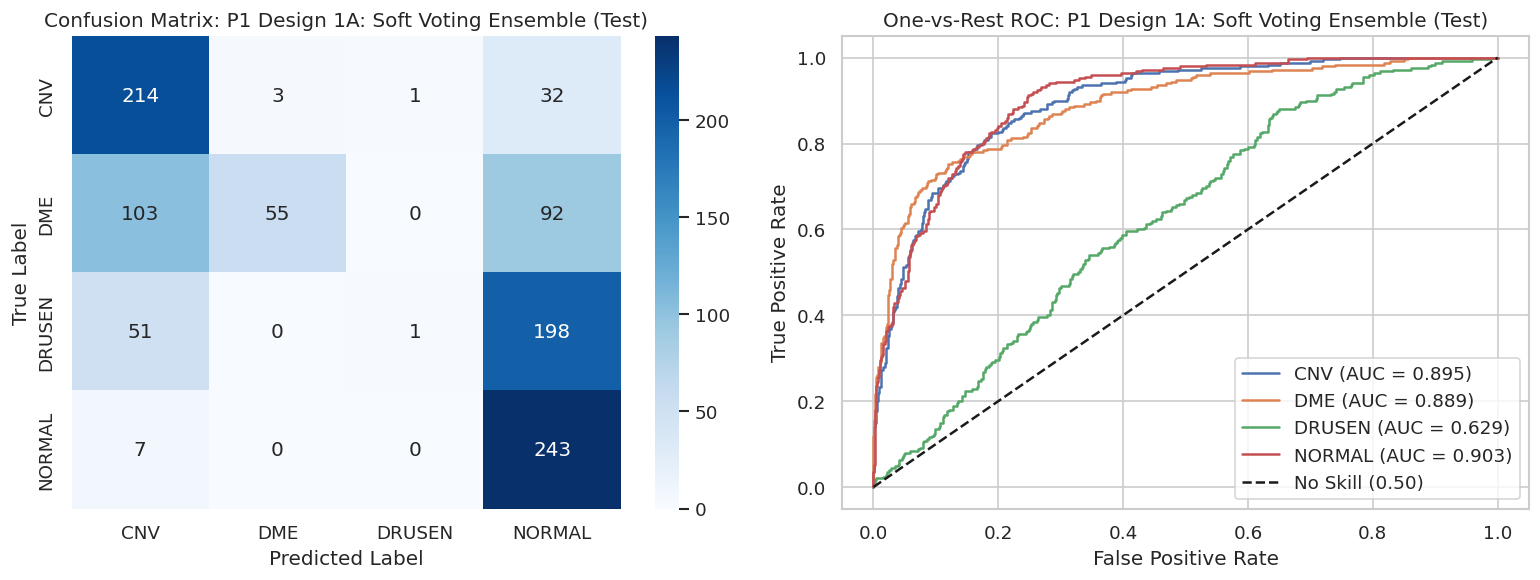

{'Model': 'P1 Design 1A: Soft Voting Ensemble',
 'Split': 'Test',
 'Accuracy': 0.513,
 'Balanced_Acc': 0.513,
 'Precision_Macro': 0.6122577560777134,
 'Recall_Macro': 0.513,
 'F1_Macro': 0.4115495958710682,
 'AUC_Macro': 0.8292}

In [7]:
# Pipeline 1 - Design 1A: Soft Voting Ensemble
print("Training Design 1A: Soft Voting Ensemble (HGB + RF + KNN)...")
t0 = time.time()

hgb_base = HistGradientBoostingClassifier(max_iter=100, random_state=42)
rf_base = RandomForestClassifier(n_estimators=100, max_depth=16, n_jobs=-1, random_state=42)
knn_base = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)

voting_clf = VotingClassifier(
    estimators=[('hgb', hgb_base), ('rf', rf_base), ('knn', knn_base)],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train_sub, y_train_sub)
print(f"Fitted in {time.time()-t0:.1f} seconds.")

# Validation & Test Evaluation
v_val_pred = voting_clf.predict(X_val_flat)
v_val_prob = voting_clf.predict_proba(X_val_flat)
evaluate_model(val_labels, v_val_pred, v_val_prob, "P1 Design 1A: Soft Voting Ensemble", "Validation", plot=False)

v_test_pred = voting_clf.predict(X_test_flat)
v_test_prob = voting_clf.predict_proba(X_test_flat)
evaluate_model(test_labels, v_test_pred, v_test_prob, "P1 Design 1A: Soft Voting Ensemble", "Test", plot=True)


Training Design 1B: PCA (90% variance) + Stacking Ensemble...


PCA reduced dimensions from 784 to 21 components.


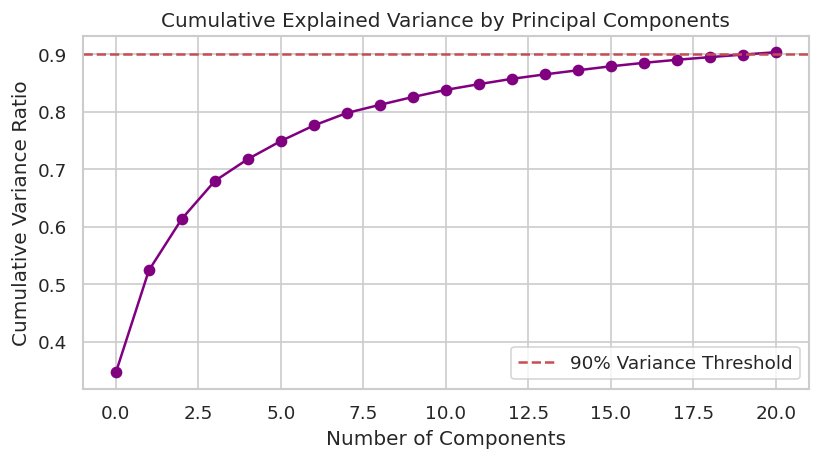

Fitted Stacking Classifier in 15.7 seconds.


=== P1 Design 1B: PCA + Stacking [Validation Set Evaluation] ===
Accuracy:          0.6458
Balanced Accuracy: 0.4194
Precision (Macro): 0.6138
Recall (Macro):    0.4194
F1-Score (Macro):  0.4088
ROC AUC (Macro):   0.7751

=== P1 Design 1B: PCA + Stacking [Test Set Evaluation] ===
Accuracy:          0.4630
Balanced Accuracy: 0.4630
Precision (Macro): 0.4276
Recall (Macro):    0.4630
F1-Score (Macro):  0.3727
ROC AUC (Macro):   0.8016



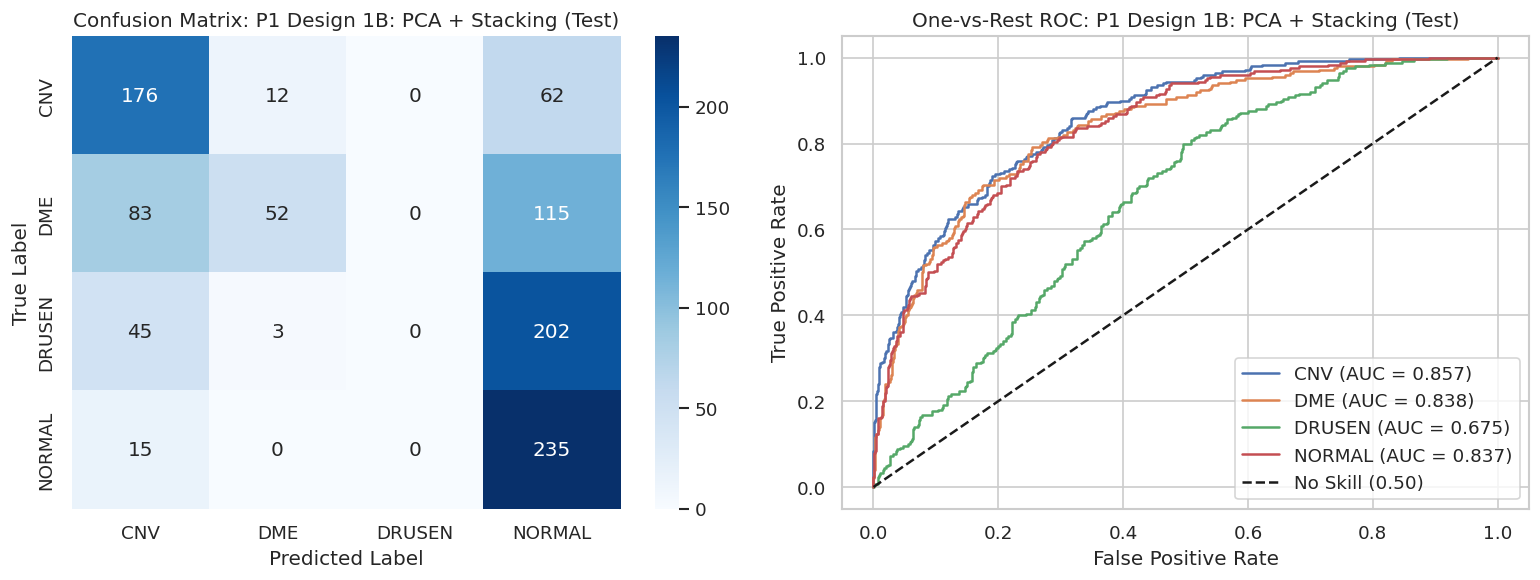

{'Model': 'P1 Design 1B: PCA + Stacking',
 'Split': 'Test',
 'Accuracy': 0.463,
 'Balanced_Acc': 0.46299999999999997,
 'Precision_Macro': 0.42764492431697515,
 'Recall_Macro': 0.46299999999999997,
 'F1_Macro': 0.37267159131252914,
 'AUC_Macro': 0.8016493333333334}

In [8]:
# Pipeline 1 - Design 1B: PCA (90% Variance) + Stacking Classifier
print("Training Design 1B: PCA (90% variance) + Stacking Ensemble...")
t0 = time.time()

pca_90 = PCA(n_components=0.90, random_state=42)
X_sub_pca = pca_90.fit_transform(X_train_sub)
X_val_pca = pca_90.transform(X_val_flat)
X_test_pca = pca_90.transform(X_test_flat)

print(f"PCA reduced dimensions from 784 to {pca_90.n_components_} components.")

# Plot cumulative explained variance
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca_90.explained_variance_ratio_), marker='o', color='purple')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.tight_layout()
plt.show()

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=14, n_jobs=-1, random_state=42)),
        ('hgb', HistGradientBoostingClassifier(max_iter=60, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=500),
    cv=3,
    n_jobs=-1
)

stacking_clf.fit(X_sub_pca, y_train_sub)
print(f"Fitted Stacking Classifier in {time.time()-t0:.1f} seconds.")

s_val_pred = stacking_clf.predict(X_val_pca)
s_val_prob = stacking_clf.predict_proba(X_val_pca)
evaluate_model(val_labels, s_val_pred, s_val_prob, "P1 Design 1B: PCA + Stacking", "Validation", plot=False)

s_test_pred = stacking_clf.predict(X_test_pca)
s_test_prob = stacking_clf.predict_proba(X_test_pca)
evaluate_model(test_labels, s_test_pred, s_test_prob, "P1 Design 1B: PCA + Stacking", "Test", plot=True)


Training Design 1C: HistGradientBoosting on 66 Custom Features...


Fitted in 9.1 seconds on full 97477 training samples.


=== P1 Design 1C: 66 Custom Features HGB [Validation Set Evaluation] ===
Accuracy:          0.7837
Balanced Accuracy: 0.5760
Precision (Macro): 0.7129
Recall (Macro):    0.5760
F1-Score (Macro):  0.5880
ROC AUC (Macro):   0.8958

=== P1 Design 1C: 66 Custom Features HGB [Test Set Evaluation] ===
Accuracy:          0.5470
Balanced Accuracy: 0.5470
Precision (Macro): 0.4909
Recall (Macro):    0.5470
F1-Score (Macro):  0.4685
ROC AUC (Macro):   0.8633



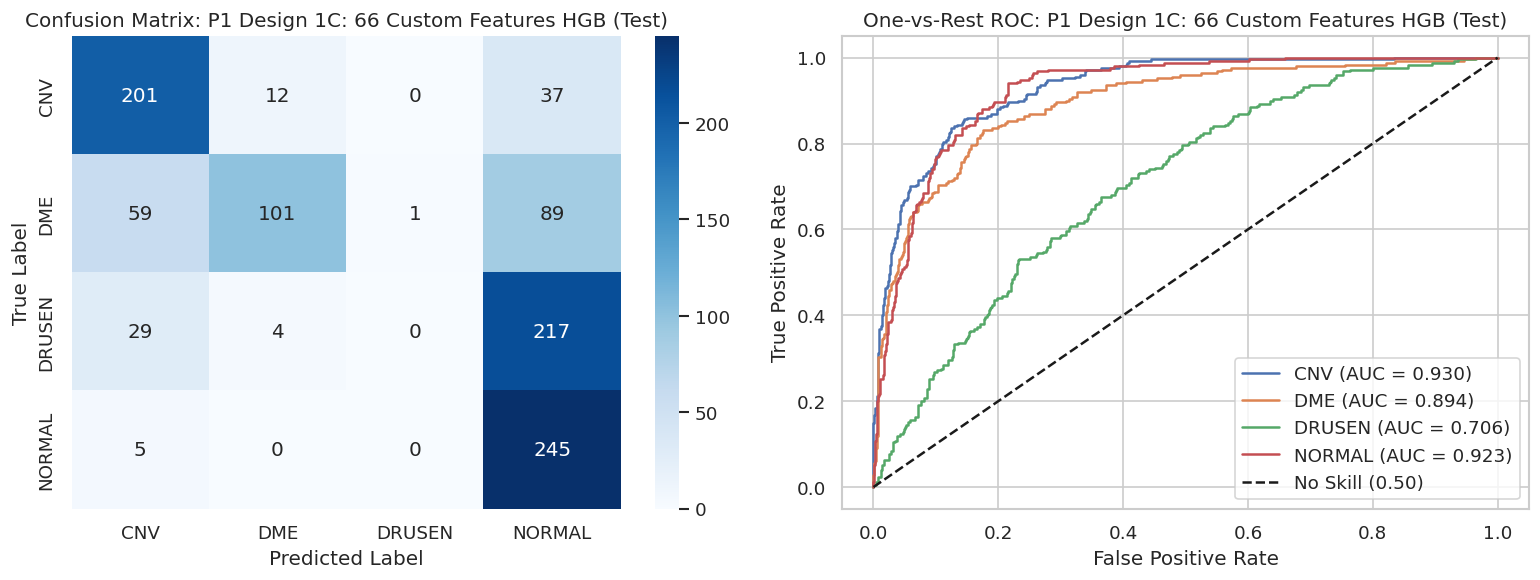

{'Model': 'P1 Design 1C: 66 Custom Features HGB',
 'Split': 'Test',
 'Accuracy': 0.547,
 'Balanced_Acc': 0.547,
 'Precision_Macro': 0.4908969998255713,
 'Recall_Macro': 0.547,
 'F1_Macro': 0.46852621114354587,
 'AUC_Macro': 0.8632533333333334}

In [9]:
# Pipeline 1 - Design 1C: HistGradientBoosting on 66 Custom Features
print("Training Design 1C: HistGradientBoosting on 66 Custom Features...")
t0 = time.time()

hgb_custom = HistGradientBoostingClassifier(
    max_iter=120,
    learning_rate=0.08,
    max_depth=10,
    random_state=42
)

hgb_custom.fit(X_train_feat_scaled, train_labels)
print(f"Fitted in {time.time()-t0:.1f} seconds on full {len(train_labels)} training samples.")

c_val_pred = hgb_custom.predict(X_val_feat_scaled)
c_val_prob = hgb_custom.predict_proba(X_val_feat_scaled)
evaluate_model(val_labels, c_val_pred, c_val_prob, "P1 Design 1C: 66 Custom Features HGB", "Validation", plot=False)

c_test_pred = hgb_custom.predict(X_test_feat_scaled)
c_test_prob = hgb_custom.predict_proba(X_test_feat_scaled)
evaluate_model(test_labels, c_test_pred, c_test_prob, "P1 Design 1C: 66 Custom Features HGB", "Test", plot=True)


Training Design 1D: Optimized HistGradientBoosting on Full Pixel Set...


Fitted in 115.9 seconds.


=== P1 Design 1D: Optimized HGB (Full) [Validation Set Evaluation] ===
Accuracy:          0.8374
Balanced Accuracy: 0.6542
Precision (Macro): 0.8218
Recall (Macro):    0.6542
F1-Score (Macro):  0.6809
ROC AUC (Macro):   0.9349

=== P1 Design 1D: Optimized HGB (Full) [Test Set Evaluation] ===
Accuracy:          0.5730
Balanced Accuracy: 0.5730
Precision (Macro): 0.6382
Recall (Macro):    0.5730
F1-Score (Macro):  0.4923
ROC AUC (Macro):   0.8747



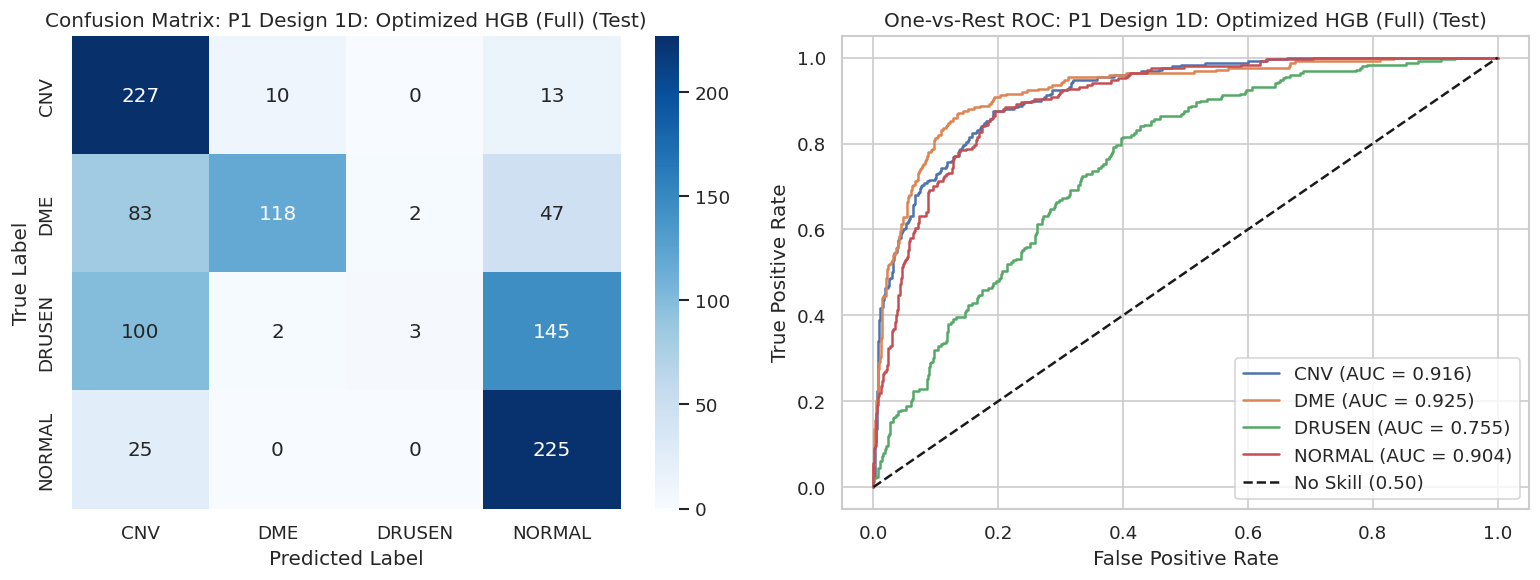

{'Model': 'P1 Design 1D: Optimized HGB (Full)',
 'Split': 'Test',
 'Accuracy': 0.573,
 'Balanced_Acc': 0.573,
 'Precision_Macro': 0.6381968005263916,
 'Recall_Macro': 0.573,
 'F1_Macro': 0.49228011796343585,
 'AUC_Macro': 0.8747320000000001}

In [10]:
# Pipeline 1 - Design 1D: Full-Dataset Optimized HistGradientBoosting
print("Training Design 1D: Optimized HistGradientBoosting on Full Pixel Set...")
t0 = time.time()

hgb_opt = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.1,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

hgb_opt.fit(X_train_flat, train_labels)
print(f"Fitted in {time.time()-t0:.1f} seconds.")

opt_val_pred = hgb_opt.predict(X_val_flat)
opt_val_prob = hgb_opt.predict_proba(X_val_flat)
evaluate_model(val_labels, opt_val_pred, opt_val_prob, "P1 Design 1D: Optimized HGB (Full)", "Validation", plot=False)

opt_test_pred = hgb_opt.predict(X_test_flat)
opt_test_prob = hgb_opt.predict_proba(X_test_flat)
evaluate_model(test_labels, opt_test_pred, opt_test_prob, "P1 Design 1D: Optimized HGB (Full)", "Test", plot=True)


---
# Pipeline 2: Artificial Neural Networks (GPU-Accelerated)

We explore three distinct deep learning architectures implemented with GPU acceleration on the **NVIDIA GeForce GTX 1660 Ti**:
* **Design 2A (Deep MLP)**: Multi-layer Dense network trained on the 66 domain-specific engineered features with Batch Normalization and Dropout.
* **Design 2B (Baseline CNN1)**: Standard 3-stage Convolutional Network with MaxPooling.
* **Design 2C (Deep CNN2 - Optimal)**: Multi-block ConvNet with Batch Normalization, Dropout, Global Average Pooling, and learning rate scheduling.


In [11]:
def train_gpu_model(model, train_loader, val_loader, epochs=10, lr=1e-3, model_title="Model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights = None
    
    print(f"\n--- Training {model_title} on {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}) ---")
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs:02d}", leave=False, ncols=85)
        for x, y in pbar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * x.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += x.size(0)
            
            pbar.set_postfix({'loss': f"{running_loss/total:.4f}", 'acc': f"{correct/total:.4f}"})
            
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Validation evaluation
        model.eval()
        v_loss, v_corr, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for vx, vy in val_loader:
                vx, vy = vx.to(device, non_blocking=True), vy.to(device, non_blocking=True)
                vout = model(vx)
                vloss = criterion(vout, vy)
                v_loss += vloss.item() * vx.size(0)
                v_corr += (vout.argmax(dim=1) == vy).sum().item()
                v_tot += vx.size(0)
                
        val_loss = v_loss / v_tot
        val_acc = v_corr / v_tot
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            
        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch:02d}/{epochs:02d} [{epoch_time:.1f}s] - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        
    print(f"Training completed in {time.time()-start_time:.1f} seconds. Restoring best model weights (Val Loss: {best_val_loss:.4f}).")
    model.load_state_dict(best_weights)
    return model, history

def predict_gpu(model, loader):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device, non_blocking=True)
            probs = torch.softmax(model(x), dim=1).cpu().numpy()
            all_probs.append(probs)
    probs_mat = np.vstack(all_probs)
    preds = np.argmax(probs_mat, axis=1)
    return preds, probs_mat

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[0].set_title(f"{title}: Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    axes[1].plot(history['train_acc'], label='Train Acc', color='blue')
    axes[1].plot(history['val_acc'], label='Val Acc', color='orange')
    axes[1].set_title(f"{title}: Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()



--- Training P2 Design 2A: Deep MLP on cuda (NVIDIA GeForce GTX 1660 Ti) ---


Epoch 01/12:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 01/12 [3.5s] - Train Loss: 0.8750, Acc: 0.6715 | Val Loss: 0.7247, Acc: 0.7406


Epoch 02/12:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 02/12 [3.3s] - Train Loss: 0.7552, Acc: 0.7262 | Val Loss: 0.6679, Acc: 0.7590


...

Epoch 10/12 [3.4s] - Train Loss: 0.6281, Acc: 0.7762 | Val Loss: 0.5639, Acc: 0.7975


Epoch 11/12:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 11/12 [3.5s] - Train Loss: 0.6196, Acc: 0.7775 | Val Loss: 0.5536, Acc: 0.8034


Epoch 12/12:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 12/12 [3.5s] - Train Loss: 0.6136, Acc: 0.7813 | Val Loss: 0.5465, Acc: 0.8030
Training completed in 41.5 seconds. Restoring best model weights (Val Loss: 0.5465).


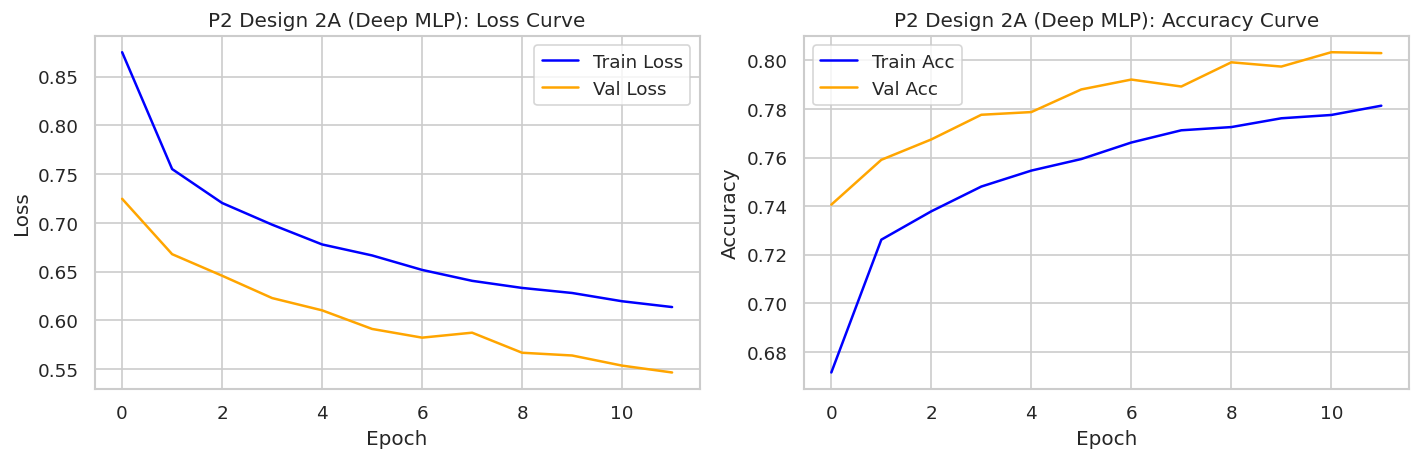

=== P2 Design 2A: Deep MLP [Validation Set Evaluation] ===
Accuracy:          0.8030
Balanced Accuracy: 0.5965
Precision (Macro): 0.7018
Recall (Macro):    0.5965
F1-Score (Macro):  0.5969
ROC AUC (Macro):   0.9117

=== P2 Design 2A: Deep MLP [Test Set Evaluation] ===
Accuracy:          0.6080
Balanced Accuracy: 0.6080
Precision (Macro): 0.4908
Recall (Macro):    0.6080
F1-Score (Macro):  0.5258
ROC AUC (Macro):   0.8925



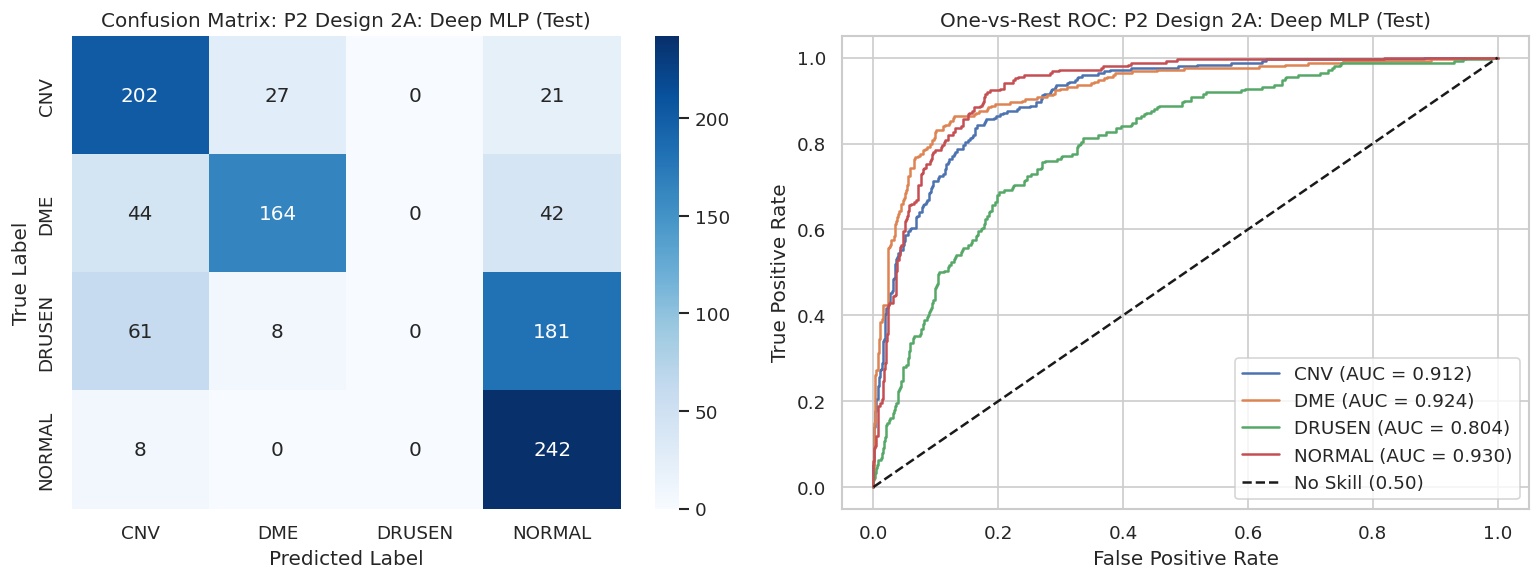

{'Model': 'P2 Design 2A: Deep MLP',
 'Split': 'Test',
 'Accuracy': 0.608,
 'Balanced_Acc': 0.608,
 'Precision_Macro': 0.4908332077790481,
 'Recall_Macro': 0.608,
 'F1_Macro': 0.5257912982207479,
 'AUC_Macro': 0.892536}

In [12]:
# Pipeline 2 - Design 2A: Deep Multi-Layer Perceptron (MLP) on 66 Custom Features
class DeepMLP(nn.Module):
    def __init__(self, in_features=66):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        return self.net(x)

# Custom feature DataLoaders
train_feat_t = torch.tensor(X_train_feat_scaled, dtype=torch.float32)
val_feat_t = torch.tensor(X_val_feat_scaled, dtype=torch.float32)
test_feat_t = torch.tensor(X_test_feat_scaled, dtype=torch.float32)

mlp_train_loader = DataLoader(TensorDataset(train_feat_t, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
mlp_val_loader = DataLoader(TensorDataset(val_feat_t, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)
mlp_test_loader = DataLoader(TensorDataset(test_feat_t, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

mlp_model = DeepMLP(66)
mlp_model, hist_mlp = train_gpu_model(mlp_model, mlp_train_loader, mlp_val_loader, epochs=12, lr=1e-3, model_title="P2 Design 2A: Deep MLP")
plot_history(hist_mlp, "P2 Design 2A (Deep MLP)")

mlp_val_pred, mlp_val_prob = predict_gpu(mlp_model, mlp_val_loader)
evaluate_model(val_labels, mlp_val_pred, mlp_val_prob, "P2 Design 2A: Deep MLP", "Validation", plot=False)

mlp_test_pred, mlp_test_prob = predict_gpu(mlp_model, mlp_test_loader)
evaluate_model(test_labels, mlp_test_pred, mlp_test_prob, "P2 Design 2A: Deep MLP", "Test", plot=True)



--- Training P2 Design 2B: Baseline CNN1 on cuda (NVIDIA GeForce GTX 1660 Ti) ---


Epoch 01/08:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 01/08 [5.4s] - Train Loss: 0.9251, Acc: 0.6342 | Val Loss: 0.7137, Acc: 0.7468


Epoch 02/08:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 02/08 [5.0s] - Train Loss: 0.6146, Acc: 0.7865 | Val Loss: 0.5303, Acc: 0.8109


...

Epoch 06/08 [5.1s] - Train Loss: 0.4112, Acc: 0.8580 | Val Loss: 0.3869, Acc: 0.8649


Epoch 07/08:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 07/08 [5.1s] - Train Loss: 0.3901, Acc: 0.8659 | Val Loss: 0.3448, Acc: 0.8795


Epoch 08/08:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 08/08 [5.2s] - Train Loss: 0.3669, Acc: 0.8742 | Val Loss: 0.3328, Acc: 0.8824
Training completed in 41.0 seconds. Restoring best model weights (Val Loss: 0.3328).


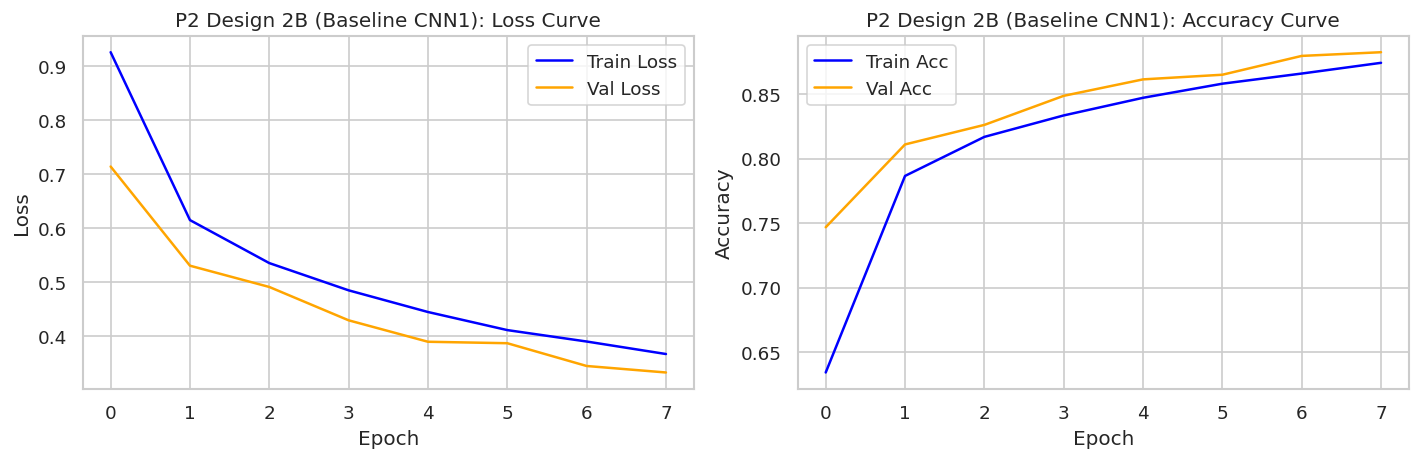

=== P2 Design 2B: Baseline CNN1 [Validation Set Evaluation] ===
Accuracy:          0.8824
Balanced Accuracy: 0.7415
Precision (Macro): 0.8072
Recall (Macro):    0.7415
F1-Score (Macro):  0.7621
ROC AUC (Macro):   0.9574

=== P2 Design 2B: Baseline CNN1 [Test Set Evaluation] ===
Accuracy:          0.7080
Balanced Accuracy: 0.7080
Precision (Macro): 0.7570
Recall (Macro):    0.7080
F1-Score (Macro):  0.6684
ROC AUC (Macro):   0.9412



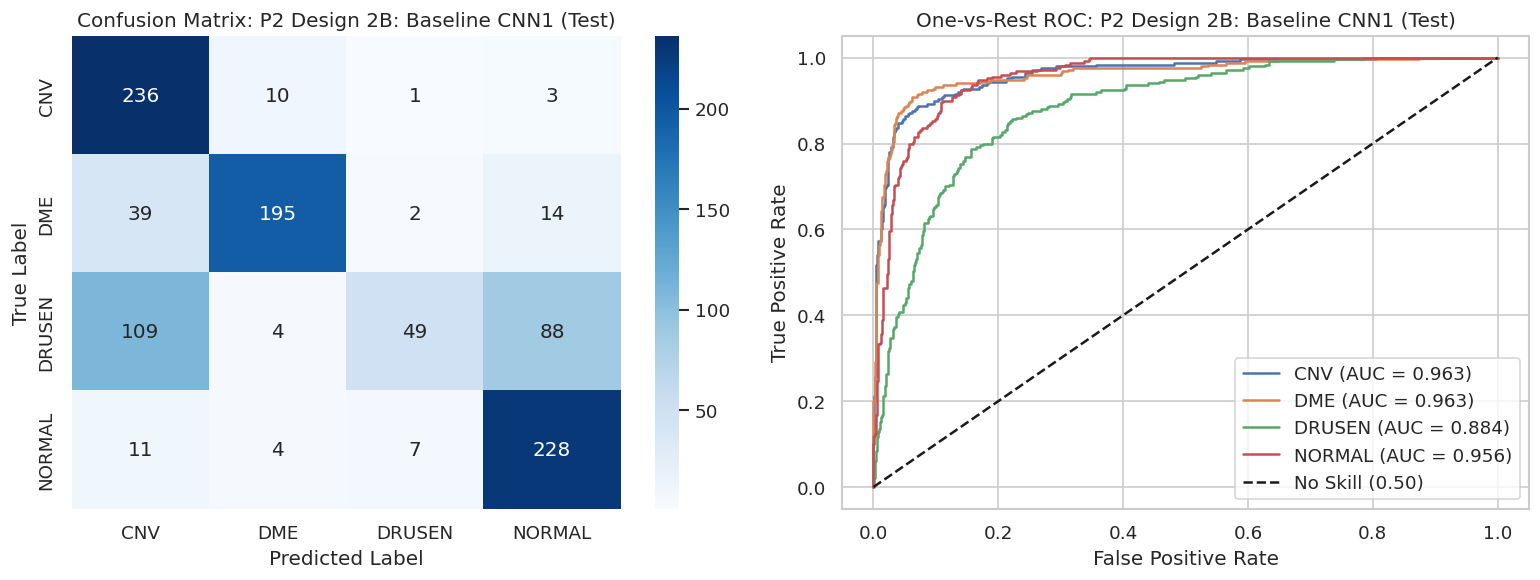

{'Model': 'P2 Design 2B: Baseline CNN1',
 'Split': 'Test',
 'Accuracy': 0.708,
 'Balanced_Acc': 0.708,
 'Precision_Macro': 0.7570386178594537,
 'Recall_Macro': 0.708,
 'F1_Macro': 0.6683572244196643,
 'AUC_Macro': 0.9412146666666668}

In [13]:
# Pipeline 2 - Design 2B: Baseline CNN1 (3-Stage ConvNet)
class BaselineCNN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 4)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

cnn1_model = BaselineCNN1()
cnn1_model, hist_cnn1 = train_gpu_model(cnn1_model, train_loader, val_loader, epochs=8, lr=1e-3, model_title="P2 Design 2B: Baseline CNN1")
plot_history(hist_cnn1, "P2 Design 2B (Baseline CNN1)")

cnn1_val_pred, cnn1_val_prob = predict_gpu(cnn1_model, val_loader)
evaluate_model(val_labels, cnn1_val_pred, cnn1_val_prob, "P2 Design 2B: Baseline CNN1", "Validation", plot=False)

cnn1_test_pred, cnn1_test_prob = predict_gpu(cnn1_model, test_loader)
evaluate_model(test_labels, cnn1_test_pred, cnn1_test_prob, "P2 Design 2B: Baseline CNN1", "Test", plot=True)



--- Training P2 Design 2C: Deep CNN2 on cuda (NVIDIA GeForce GTX 1660 Ti) ---


Epoch 01/10:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 01/10 [9.4s] - Train Loss: 0.6627, Acc: 0.7688 | Val Loss: 0.4439, Acc: 0.8467


Epoch 02/10:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 02/10 [9.3s] - Train Loss: 0.4594, Acc: 0.8463 | Val Loss: 0.3802, Acc: 0.8713


...

Epoch 08/10 [9.7s] - Train Loss: 0.2912, Acc: 0.9028 | Val Loss: 0.2854, Acc: 0.9053


Epoch 09/10:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 09/10 [9.8s] - Train Loss: 0.2810, Acc: 0.9056 | Val Loss: 0.3029, Acc: 0.9066


Epoch 10/10:   0%|                                           | 0/381 [00:00<?, ?it/s]

Epoch 10/10 [9.7s] - Train Loss: 0.2773, Acc: 0.9066 | Val Loss: 0.2510, Acc: 0.9155
Training completed in 95.4 seconds. Restoring best model weights (Val Loss: 0.2510).


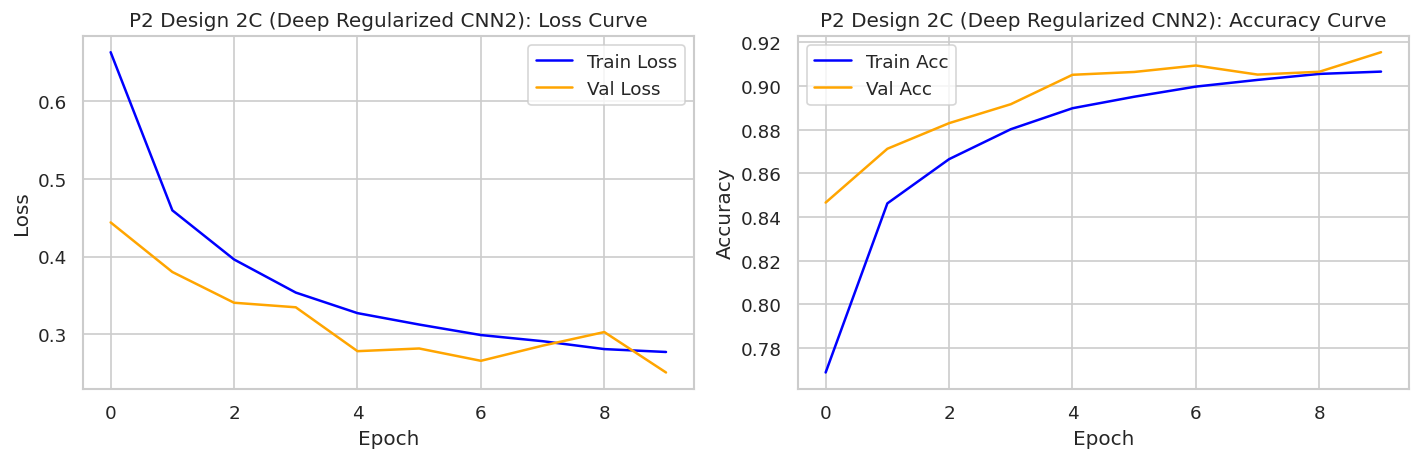

=== P2 Design 2C: Deep CNN2 [Validation Set Evaluation] ===
Accuracy:          0.9155
Balanced Accuracy: 0.7999
Precision (Macro): 0.8867
Recall (Macro):    0.7999
F1-Score (Macro):  0.8288
ROC AUC (Macro):   0.9725

=== P2 Design 2C: Deep CNN2 [Test Set Evaluation] ===
Accuracy:          0.7300
Balanced Accuracy: 0.7300
Precision (Macro): 0.8085
Recall (Macro):    0.7300
F1-Score (Macro):  0.6906
ROC AUC (Macro):   0.9619



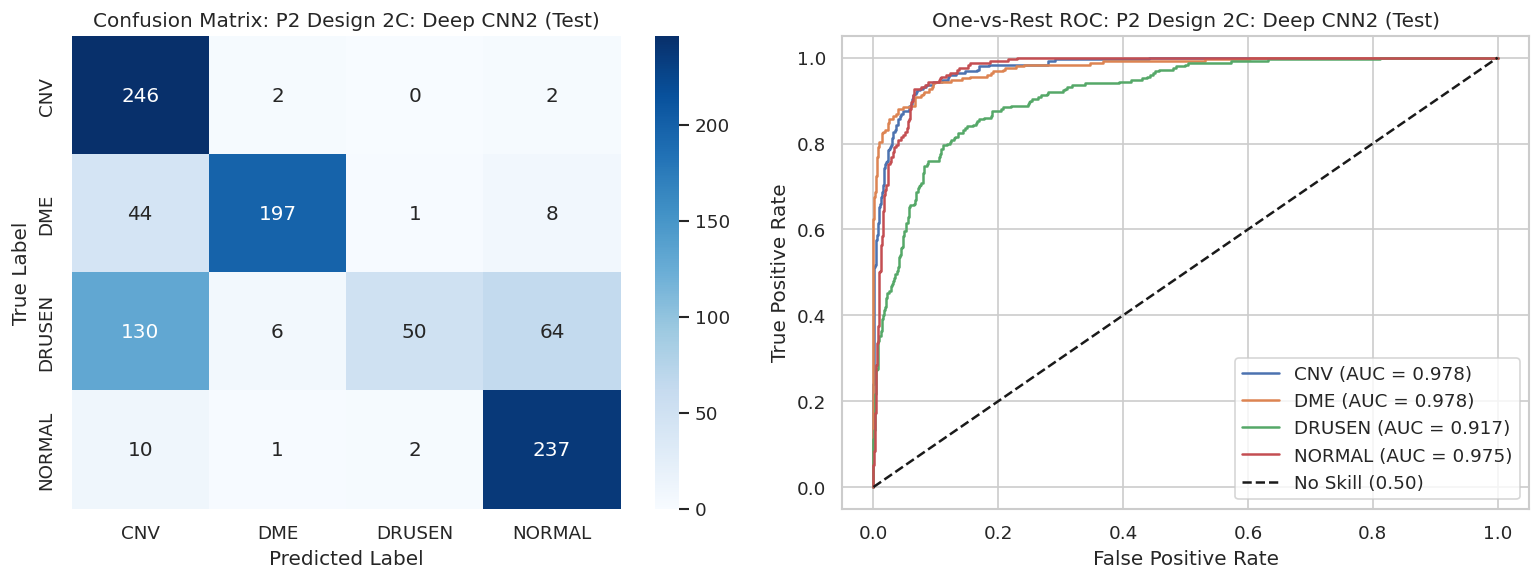

{'Model': 'P2 Design 2C: Deep CNN2',
 'Split': 'Test',
 'Accuracy': 0.73,
 'Balanced_Acc': 0.73,
 'Precision_Macro': 0.8084644517740159,
 'Recall_Macro': 0.73,
 'F1_Macro': 0.6906293222201477,
 'AUC_Macro': 0.9618906666666667}

In [14]:
# Pipeline 2 - Design 2C: Deep Regularized CNN2 (Optimal Architecture)
class DeepRegularizedCNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 4)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

cnn2_model = DeepRegularizedCNN2()
cnn2_model, hist_cnn2 = train_gpu_model(cnn2_model, train_loader, val_loader, epochs=10, lr=1e-3, model_title="P2 Design 2C: Deep CNN2")
plot_history(hist_cnn2, "P2 Design 2C (Deep Regularized CNN2)")

cnn2_val_pred, cnn2_val_prob = predict_gpu(cnn2_model, val_loader)
evaluate_model(val_labels, cnn2_val_pred, cnn2_val_prob, "P2 Design 2C: Deep CNN2", "Validation", plot=False)

cnn2_test_pred, cnn2_test_prob = predict_gpu(cnn2_model, test_loader)
evaluate_model(test_labels, cnn2_test_pred, cnn2_test_prob, "P2 Design 2C: Deep CNN2", "Test", plot=True)


---
# Comprehensive Multi-Model Comparative Synthesis


=== FINAL TEST SET PERFORMANCE COMPARISON ===
                               Model  Accuracy  Balanced_Acc  Precision_Macro  Recall_Macro  F1_Macro  AUC_Macro
             P2 Design 2C: Deep CNN2     0.730         0.730         0.808464         0.730  0.690629   0.961891
         P2 Design 2B: Baseline CNN1     0.708         0.708         0.757039         0.708  0.668357   0.941215
              P2 Design 2A: Deep MLP     0.608         0.608         0.490833         0.608  0.525791   0.892536
  P1 Design 1D: Optimized HGB (Full)     0.573         0.573         0.638197         0.573  0.492280   0.874732
P1 Design 1C: 66 Custom Features HGB     0.547         0.547         0.490897         0.547  0.468526   0.863253
  P1 Design 1A: Soft Voting Ensemble     0.513         0.513         0.612258         0.513  0.411550   0.829200
        P1 Design 1B: PCA + Stacking     0.463         0.463         0.427645         0.463  0.372672   0.801649


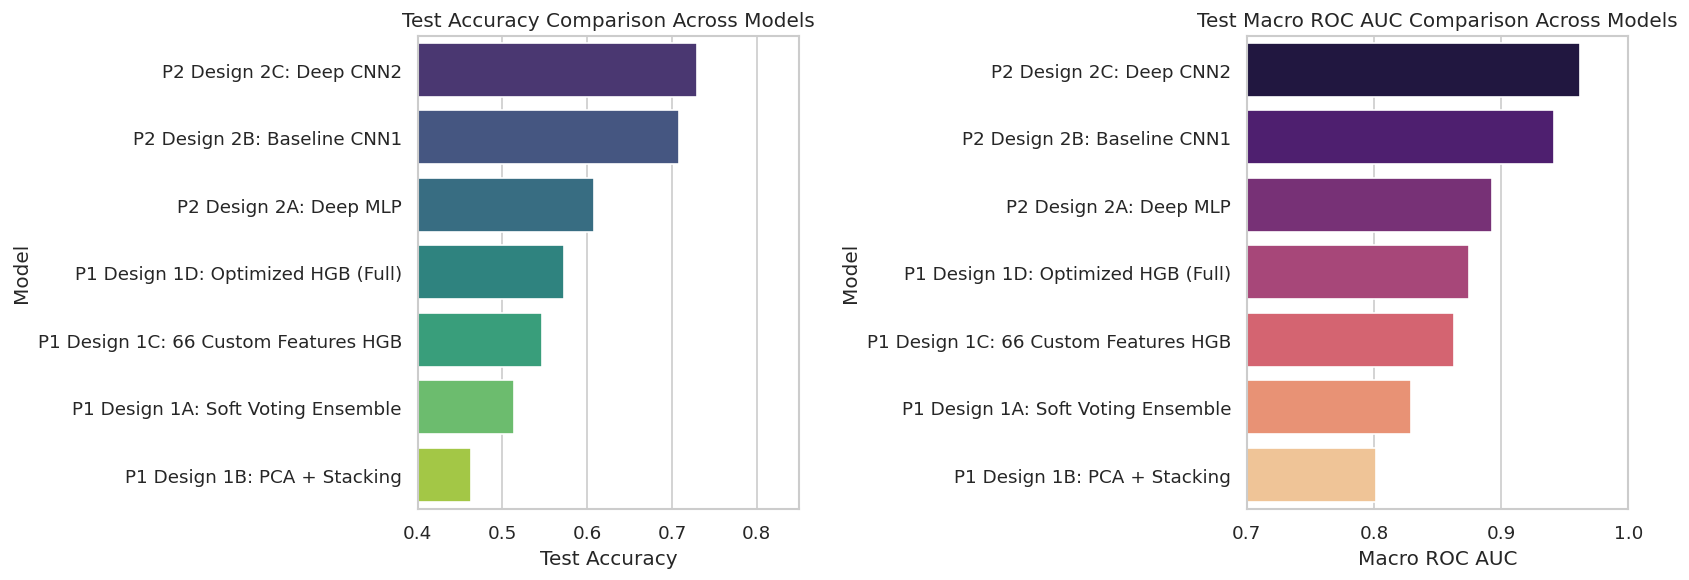

In [15]:
# Compile and display full metrics comparison dataframe
df_results = pd.DataFrame(results_records)
df_results_test = df_results[df_results['Split'] == 'Test'].sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("=== FINAL TEST SET PERFORMANCE COMPARISON ===")
display_cols = ['Model', 'Accuracy', 'Balanced_Acc', 'Precision_Macro', 'Recall_Macro', 'F1_Macro', 'AUC_Macro']
print(df_results_test[display_cols].to_string(index=False))

# Plot Test Accuracy and Test AUC comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_results_test, x='Accuracy', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title("Test Accuracy Comparison Across Models")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_xlim(0.4, 0.85)

sns.barplot(data=df_results_test, x='AUC_Macro', y='Model', palette='magma', ax=axes[1])
axes[1].set_title("Test Macro ROC AUC Comparison Across Models")
axes[1].set_xlabel("Macro ROC AUC")
axes[1].set_xlim(0.7, 1.0)

plt.tight_layout()
plt.show()


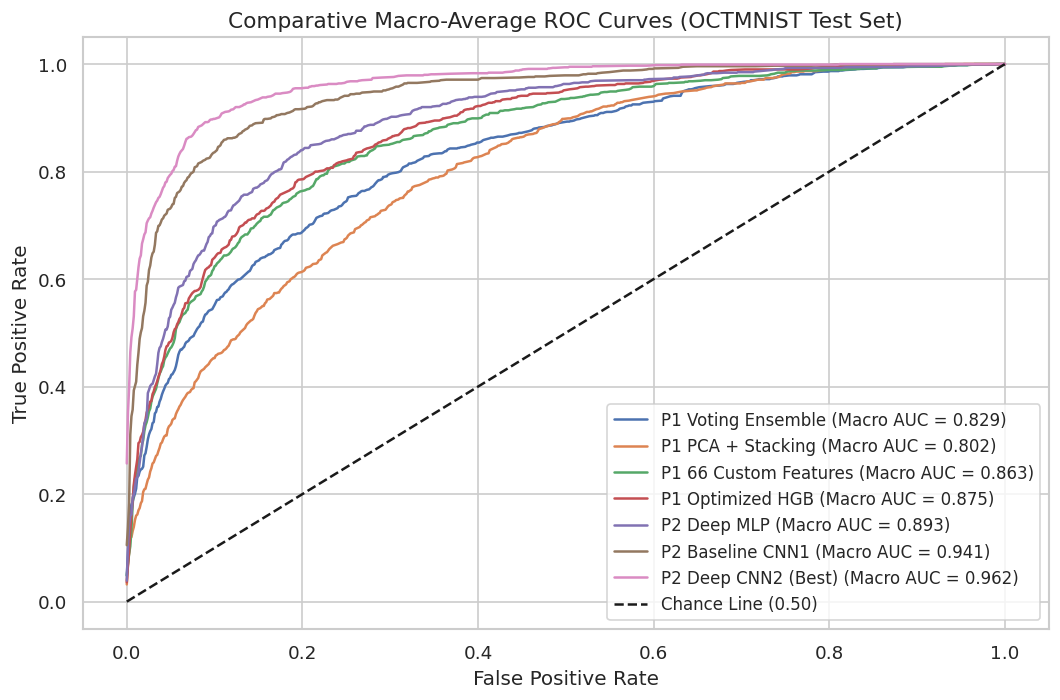

In [16]:
# Combined ROC Curve of all models on the Test Set
plt.figure(figsize=(9, 6))

model_probs = [
    ("P1 Voting Ensemble", v_test_prob),
    ("P1 PCA + Stacking", s_test_prob),
    ("P1 66 Custom Features", c_test_prob),
    ("P1 Optimized HGB", opt_test_prob),
    ("P2 Deep MLP", mlp_test_prob),
    ("P2 Baseline CNN1", cnn1_test_prob),
    ("P2 Deep CNN2 (Best)", cnn2_test_prob),
]

y_test_bin = label_binarize(test_labels, classes=range(4))

for name, probs in model_probs:
    macro_auc = roc_auc_score(test_labels, probs, multi_class='ovr', average='macro')
    all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], probs[:, i])[0] for i in range(4)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(4):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= 4.0
    plt.plot(all_fpr, mean_tpr, label=f"{name} (Macro AUC = {macro_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance Line (0.50)')
plt.title("Comparative Macro-Average ROC Curves (OCTMNIST Test Set)", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()
